# England LSOA Population Age Structure Analysis

**Author:** Pavel Trofimchik  
**Context:** Statistics coursework, MSc Data Science & AI, Queen Mary University of London (2025–26)  
**Repository:** [github.com/TrPavel/lsoa-population-analysis](https://github.com/TrPavel/lsoa-population-analysis)

Statistical analysis of demographic age profiles across ~33,000 LSOAs in England.

# England Age Profile

Computing England-wide proportions for each 5-year age band from LSOA-level census data.

Mismatched rows (sum(age)!=Total): 0 / 33755


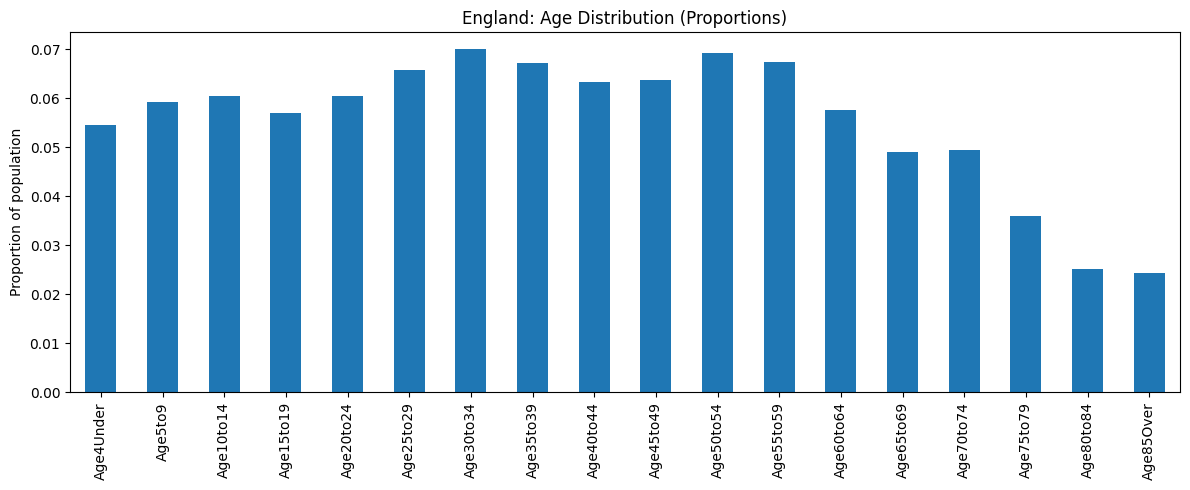

In [2]:
import os
os.makedirs('../figures', exist_ok=True)

import pandas as pd

df = pd.read_csv(
    "../data/LSOA_data.csv",
    dtype={"LSOACode": "string", "PartOfCode": "string"}
)

#Identify age columns and validate totals 
age_cols = [c for c in df.columns if c.startswith("Age")]
assert "Total" in df.columns, "Column 'Total' is missing."

#Sanity check
row_sums = df[age_cols].sum(axis=1)
mismatch_count = (row_sums != df["Total"]).sum()
print(f"Mismatched rows (sum(age)!=Total): {mismatch_count} / {len(df)}")

#England-wide proportions for each age band
england_age_totals = df[age_cols].sum() # sum across all LSOAs
england_total = england_age_totals.sum()
england_props = (england_age_totals / england_total) # proportions by age band

#Bar chart
chart = (england_props).plot(kind="bar", figsize=(12, 5),title="England: Age Distribution (Proportions)")
chart.set_ylabel("Proportion of population")
chart.figure.tight_layout()

chart.figure.savefig('../figures/england_age_profile.png', dpi=150, bbox_inches='tight')


# Analysis — England profile

England’s profile is middle-heavy with two visible humps: one around 30–39 and another around 50–59. Proportions decline steadily after around 60, with a clear decline after 75+. Children (0–14) and late teens/early 20s are below the mid-life curve

# Local vs National Comparison

Comparing age-band proportions for three representative LSOAs (Bury, Dorset, Birmingham) against the England-wide profile.

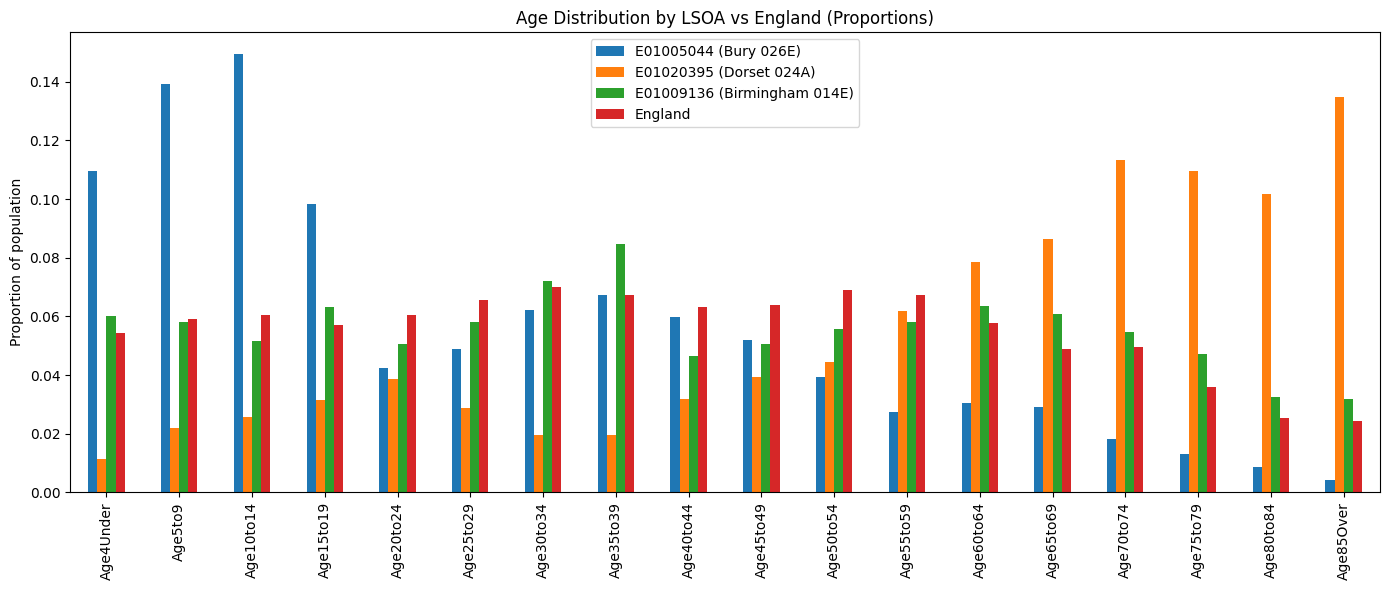

In [3]:
#3 target LSOAs
targets = {
    "E01005044": "E01005044 (Bury 026E)",
    "E01020395": "E01020395 (Dorset 024A)",
    "E01009136": "E01009136 (Birmingham 014E)"
}

#For each LSOA compute proportions by age band and append to list
series = []
for code, label in targets.items():
    row = df.loc[df["LSOACode"] == code]
    row = row.iloc[0]
    series.append((row[age_cols] / row["Total"]).rename(label))

#Add England as reference
series.append(england_props.rename("England"))

compare = pd.concat(series, axis=1) #index: age bands, columns: areas

#Grouped bar chart 
chart = compare.plot(kind="bar", figsize=(14, 6),title="Age Distribution by LSOA vs England (Proportions)")
chart.set_ylabel("Proportion of population")
chart.figure.tight_layout()

chart.figure.savefig('../figures/lsoa_comparison.png', dpi=150, bbox_inches='tight')


### Analysis — LSOAs vs England:

### E01005044 (Bury 026E): the left side of the chart (0–14) sits above England, pointing to a younger child profile than the national average

### E01020395 (Dorset 024A): a sustained elevation across the older tail (65–84 and 85+) relative to England, indicating a markedly older local age structure

### E01009136 (Birmingham 014E): working-age bands (30–39) are at or above England. Older bands (70+) are broadly similar to England overall; a few (e.g., 75–79, 85+) are slightly higher, but nowhere near the strong uplift seen in Dorset


# Why Local Profiles Differ

- **Education hubs** (universities/colleges) draw 15–24, raising young-adult shares

- **Retirement/coastal/rural destinations** attract older movers and retain fewer young adults, lifting 65+ proportions

- **Urban job markets and new housing** pull 25–49, raising working-age bands

- **Migration, housing affordability, and family formation** patterns (areas with more young families vs. single professionals) shift the left-hand (0–14) and middle bands

- These drivers vary locally, so an LSOA can be meaningfully **younger or older** than England even after normalising by population size

# Derived Metrics

Adding three per-LSOA derived columns: proportion of younger residents (0–19), proportion of older residents (65+), and estimated median age using linear interpolation within 5-year bands.

In [4]:
#Age bands in order
age_order = [
    "Age4Under","Age5to9","Age10to14","Age15to19",
    "Age20to24","Age25to29","Age30to34","Age35to39",
    "Age40to44","Age45to49","Age50to54","Age55to59",
    "Age60to64","Age65to69","Age70to74","Age75to79",
    "Age80to84","Age85Over"
]
younger_cols = ["Age4Under","Age5to9","Age10to14","Age15to19"]
older_cols   = ["Age65to69","Age70to74","Age75to79","Age80to84","Age85Over"]

#Younger proportion (0–19)
df["younger_prop"] = df[younger_cols].sum(axis=1) / df["Total"]

#Older proportion (65+)
df["older_prop"] = df[older_cols].sum(axis=1) / df["Total"]

#Median age
lower_bounds = [0,5,10,15,20,25,30,35,40,45,50,55,60,65,70,75,80,85]

def median_age_row(row):
    counts = row[age_order].values.astype("float64")
    T = float(row["Total"])
    if T <= 0:
        return float("nan")
    cum = counts.cumsum()
    half = 0.5 * T
    
    # index of first band where cumulative >= half
    idx = (cum >= half).argmax()
    L = float(lower_bounds[idx])
    prev_cum = 0.0 if idx == 0 else float(cum[idx-1])
    band_count = float(counts[idx])
    if band_count <= 0:
        return L

    #linear interpolation inside a 5-year band
    within = (half - prev_cum) / band_count
    return L + 5.0 * max(0.0, min(1.0, within))

df["median_age"] = df.apply(median_age_row, axis=1)

#Sanity check
assert df["younger_prop"].between(0,1).all()
assert df["older_prop"].between(0,1).all()

#New columns
df[["LSOACode","Total","younger_prop","older_prop","median_age"]].head()

,LSOACode,Total,younger_prop,older_prop,median_age
0,E01000001,1473,0.095723,0.251188,44.276316
1,E01000002,1384,0.079480,0.200145,43.913043
2,E01000003,1613,0.078735,0.176689,43.896396
3,E01000005,1101,0.200727,0.094460,34.851695
4,E01000006,1842,0.277959,0.085776,34.454023


# Distribution Analysis

Summarising and visualising the variation in total population, age proportions, and median ages across all LSOAs.

,Total,younger_prop,older_prop,median_age
count,33755.000000,33755.000000,33755.000000,33755.000000
mean,1673.532543,0.227832,0.189168,42.032147
std,353.289631,0.055301,0.085520,7.782742
min,999.000000,0.018081,0.000736,14.530516
25%,1443.000000,0.192297,0.123995,36.128752
50%,1608.000000,0.223183,0.182751,41.460674
75%,1835.000000,0.258689,0.246851,47.821934
max,9900.000000,0.628793,0.655409,71.875000


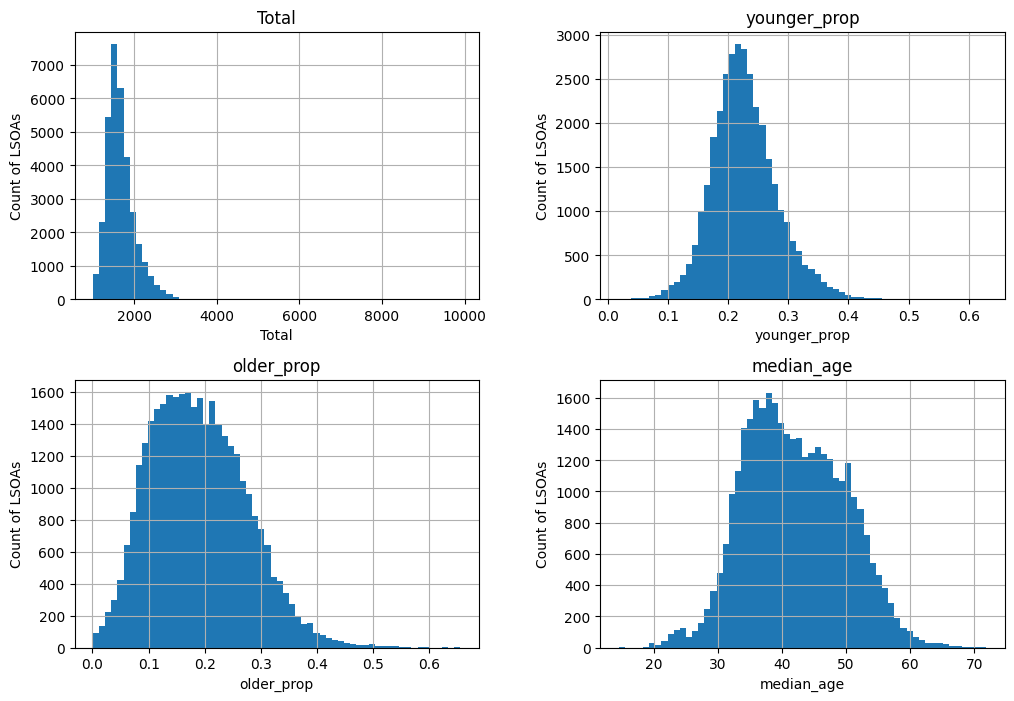

In [5]:
#Summary statistics
summary = df[["Total", "younger_prop", "older_prop", "median_age"]].describe()
display(summary)

#Histograms Layout
cols = ["Total", "younger_prop", "older_prop", "median_age"]
axes = df[cols].hist(
    bins=60,
    figsize=(12, 8),
    layout=(2, 2),
)
for ax, col in zip(axes.flatten(), cols):
    ax.set_xlabel(col)
    ax.set_ylabel("Count of LSOAs")

fig = axes.flatten()[0].figure
fig.savefig('../figures/distributions.png', dpi=150, bbox_inches='tight')


# Analysis:

- Most LSOAs have populations near 1,000–2,000

- Youth and older shares each cluster around 20%, showing broadly balanced demographics

- Median ages centre around 40 years, confirming a middle-aged national profile

Together, these plots reveal that local areas differ modestly, but extreme youth or elderly dominance is rare

# National Median Age Estimate

Estimating England's national median age from aggregated census counts and comparing it against the median of LSOA-level medians.

In [6]:
#Sum age counts across all LSOAs to get total counts for England
eng_counts = df[[c for c in df.columns if c.startswith("Age")]].sum()
eng_total = eng_counts.sum()

#Compute cumulative share
eng_cumshare = eng_counts.cumsum() / eng_total

#Age band lower bounds (to align with cumulative order)
age_bounds = [0,5,10,15,20,25,30,35,40,45,50,55,60,65,70,75,80,85]

#Locate first band where cumulative >= 0.5
idx = (eng_cumshare >= 0.5).argmax()
prev = 0 if idx == 0 else eng_cumshare.iloc[idx-1]
band = eng_cumshare.iloc[idx] - prev
within = (0.5 - prev) / band
eng_median_age = age_bounds[idx] + 5 * within

print(f"Estimated median age for England: {eng_median_age:.1f} years")

#50th percentile (median) of LSOA median ages
lsoa_median_of_medians = df["median_age"].median()
print(f"50th percentile (median) of LSOA median ages: {lsoa_median_of_medians:.1f} years")


Estimated median age for England: 40.4 years
50th percentile (median) of LSOA median ages: 41.5 years


# Results summary:

Both approaches yield at around 40 years, demonstrating consistency

## Why they differ slightly:

- **Population weighting:** The national median weights individuals, not areas

- **Local variation**: Older rural and younger urban areas balance differently

- **Age bands:** 5-year intervals introduce rounding differences

**The near-equal results confirm internal consistency and show that local demographic medians accurately reflect the overall population age structure**

# Median Age by Area Type

Comparing the distributions of median ages across four area types derived from the PartOfCode prefix: Unitary Authorities (E06), Non-metropolitan Districts (E07), Metropolitan Districts (E08), and London Boroughs (E09).

AreaType
Non-metropolitan Districts    12599
Unitary Authorities            8827
Metropolitan Districts         7335
London Boroughs                4994
Name: count, dtype: int64


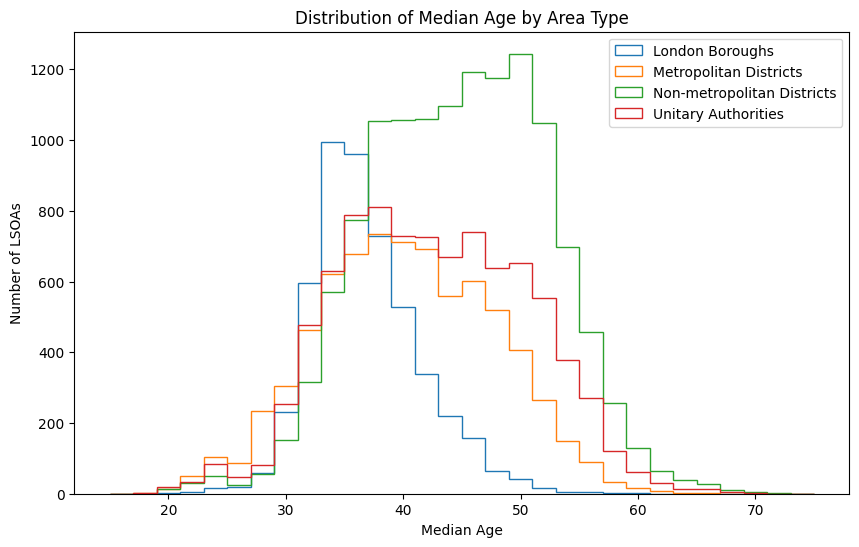

In [7]:
#Add AreaType based on PartOfCode first 3 chars
area_map = {
    "E06": "Unitary Authorities",
    "E07": "Non-metropolitan Districts",
    "E08": "Metropolitan Districts",
    "E09": "London Boroughs"
}

#Extract first 3 chars and map to area type
df["AreaType"] = df["PartOfCode"].str[:3].map(area_map)

#Sanity check 
print(df["AreaType"].value_counts(dropna=False))

# Define bins wide enough to cover all ages
bins = range(15, 76, 2)
ax = None
for area, group in df.groupby("AreaType"):
    ax = group["median_age"].plot(
        kind="hist",
        bins=bins,
        histtype="step",
        label=area,
        figsize = (10, 6),
        legend =True
    )

ax.set_xlabel("Median Age")
ax.set_ylabel("Number of LSOAs")
ax.set_title("Distribution of Median Age by Area Type")

ax.figure.savefig('../figures/median_age_by_area.png', dpi=150, bbox_inches='tight')


# Analysis: 
## Observation summary:

### London Boroughs (E09):

- The histogram is concentrated toward lower median ages (around 30–38 years)

- This reflects London’s younger, highly urban population — driven by migration, students, and early-career professionals

### Metropolitan Districts (E08):

- Slightly older profile than London, typically centred around the late 30s to early 40s

- These areas mix working-age populations with established suburban communities

### Unitary Authorities (E06):

- Show a wider spread but mostly around the 40–45 range

- These include both urban and semi-rural towns, producing a mixed demographic structure

### Non-metropolitan Districts (E07):

- Skewed toward higher median ages (peaking around 45–50)

- These areas are more rural and often attract older populations or retirees, resulting in visibly older age structures

# Younger vs Older: Scatter Analysis

Visualising how the proportions of younger (0–19) and older (65+) residents vary across LSOAs, with each dot representing one LSOA.

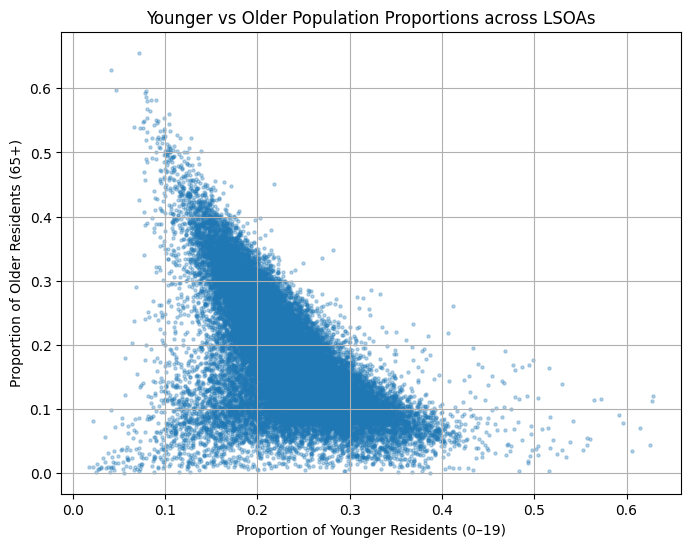

In [8]:
#Relevant columns
x = df["younger_prop"]
y = df["older_prop"]

#Scatter plot
ax = df.plot.scatter(
    x="younger_prop",
    y="older_prop",
    s=5, 
    alpha=0.3,
    figsize=(8, 6),
    grid=True,
    title="Younger vs Older Population Proportions across LSOAs"
)

ax.set_xlabel("Proportion of Younger Residents (0–19)")
ax.set_ylabel("Proportion of Older Residents (65+)")

ax.figure.savefig('../figures/younger_vs_older.png', dpi=150, bbox_inches='tight')


# Analysis on the Scatter Shape

## The scatter has a distinct triangular shape, which is expected because:

- The proportions of “younger” and “older” residents must sum (with all other age groups) to 1
  
- When an area has a high proportion of older people, it naturally has a low proportion of younger people, and vice versa

## Main cluster (center triangle area):

- Most points lie in the middle, around:

1. younger_prop around 0.20–0.25

2. older_prop around 0.15–0.25

- These represent typical or balanced LSOAs — neither particularly young nor old

### Extreme corners:

1. Upper-left corner:

- High older proportion (0.4–0.6), low younger proportion (< 0.1)

- Likely retirement or rural areas with older populations

2. Lower-right corner:

- High younger proportion (> 0.3), low older proportion (< 0.1)

- Suggests family-oriented or suburban zones with many children

3. Lower-left corner:

- Low proportions of both young and old

- Indicates “working-age” or urban professional areas, where most residents are 20–60

# Age Structure Classification

Classifying LSOAs into four demographic profiles based on their younger/older proportions:
- **Young Families:** younger_prop > 0.30, older_prop < 0.10
- **Elderly Areas:** younger_prop < 0.10, older_prop > 0.30
- **Working-age Zones:** younger_prop < 0.15, older_prop < 0.15
- **Normal:** everything else

In [9]:
#LSOAs by younger/older proportions
def classify_age_profile(row):
    y = row["younger_prop"]
    o = row["older_prop"]

    if y > 0.30 and o < 0.10:
        return "Young Families"
    elif y < 0.10 and o > 0.30:
        return "Elderly Areas"
    elif y < 0.15 and o < 0.15:
        return "Working-age Zones"
    else:
        return "Normal"

df["AgeProfileClass"] = df.apply(classify_age_profile, axis=1)
print(df["AgeProfileClass"].value_counts())

AgeProfileClass
Normal               31113
Young Families        1933
Working-age Zones      620
Elderly Areas           89
Name: count, dtype: int64


# Reflection

- Most LSOAs fall in the Normal group, forming the dense central triangle.
  
- The three smaller categories reflect the triangle’s corners from the previous graph:

1. upper-left — older retirement zones, the smallest category (89)

2. lower-right — younger family areas, the largest category (1933)

3. lower-left — mainly working-age districts (620)

4. Most other LSOAs fall within the central region and are classified as normal (31113)

# Age Classes by Area Type

Summarising and visualising how the unusual demographic classes (excluding Normal) vary across the four main area types.

AgeProfileClass,Elderly Areas,Working-age Zones,Young Families
AreaType,,,
London Boroughs,0,272,366
Metropolitan Districts,5,149,706
Non-metropolitan Districts,56,62,321
Unitary Authorities,28,137,540


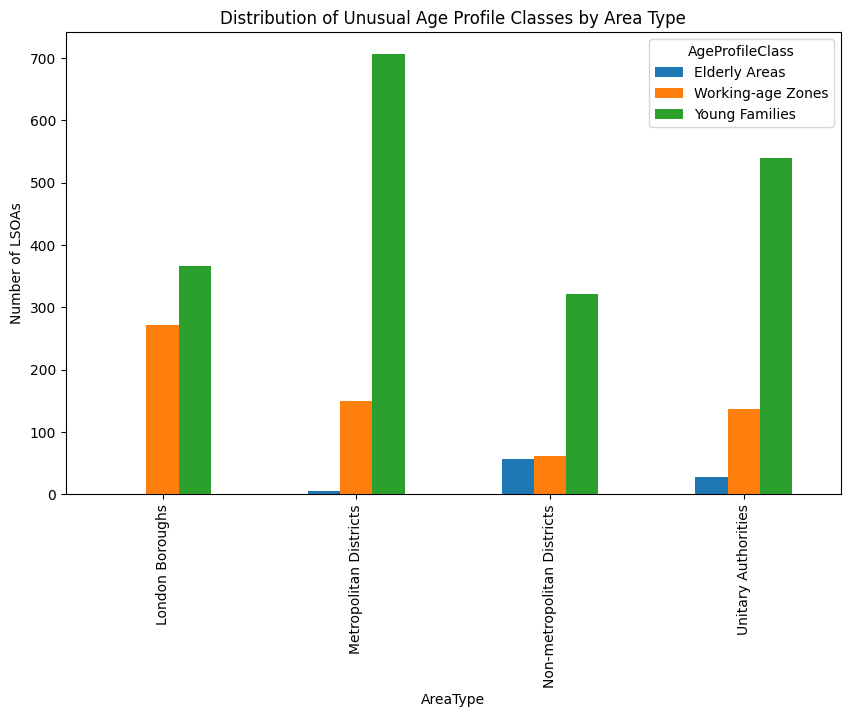

In [10]:
import matplotlib.pyplot as plt

#Create pivot table: counts of classes by area type
pivot_counts = pd.pivot_table(
    df,
    index="AreaType",
    columns="AgeProfileClass",
    values="LSOACode",
    aggfunc="count",
    fill_value=0
)

#Remove 'Normal' column for clarity
pivot_counts_no_normal = pivot_counts.drop(columns=["Normal"], errors="ignore")

#Pivot table
display(pivot_counts_no_normal)

#Bar chart
ax_classes = pivot_counts_no_normal.plot(
    kind="bar",
    figsize=(10, 6),
    grid=False,
    title="Distribution of Unusual Age Profile Classes by Area Type"
)
ax_classes.set_ylabel("Number of LSOAs")
plt.savefig('../figures/age_classes_by_area.png', dpi=150, bbox_inches='tight')

# Analysis

The chart highlights how different area types contain distinct demographic extremes:

- Young Families are most frequent in Metropolitan Districts and Unitary Authorities, reflecting younger suburban and semi-urban family populations

- Working-age Zones are concentrated in London Boroughs, consistent with inner-city, professional, and commuter populations

- Elderly Areas appear mainly in Non-metropolitan Districts and Unitary Authorities, matching expectations for rural or coastal retirement regions

Overall, the results show that urban regions (London and major cities) are dominated by working-age and young families, while rural and less dense areas tend to have older populations, confirming the demographic contrasts identified in earlier analyses